# Movie Rating Prediction — Data Cleaning and Preprocessing

**Notebook:** `02_data_preprocessing.ipynb`
**Depends on:** findings from `01_dataset_audit.ipynb`
**Reusable code:** `src/data_preprocessing.py`

No model is trained and no train/test split is made in this notebook. The raw CSV is only read.

## 1. Objective

Turn the raw IMDb India data into a **supervised modeling dataframe** and prepare a **leakage-safe feature
transformer** that later phases can fit on training data only.

The work is split into two layers, implemented in `src/data_preprocessing.py`:

| Layer | What it does | Safe to apply before splitting? |
|---|---|---|
| **Row-wise cleaning** (`clean_movies`, `build_modeling_frame`) | Parses text into numbers, strips whitespace, removes exact duplicate rows, keeps rated rows | **Yes.** Each row is processed on its own; no statistics are computed across rows |
| **Fitted transformer** (`build_feature_transformer`) | Imputes missing values, builds the genre vocabulary, counts director/actor frequencies | **No.** It learns from data, so it must be fitted on the training split only |

`Rating` is never an input to any feature computation.

## 2. Load Raw Dataset

In [1]:
import hashlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.exceptions import NotFittedError

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "dataset" / "IMDb Movies India.csv"
FIG_DIR = PROJECT_ROOT / "visualizations"
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import data_preprocessing as dp

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

PRIMARY = "#2a78d6"
MUTED = "#52514e"
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110, "axes.edgecolor": "#c9c8c2", "axes.titleweight": "bold", "axes.titlesize": 12,
    "grid.color": "#e6e5e0", "xtick.color": MUTED, "ytick.color": MUTED,
})

print(f"Dataset path: {DATA_PATH.relative_to(PROJECT_ROOT)}")

Dataset path: dataset\IMDb Movies India.csv


In [2]:
raw = dp.load_raw_data(DATA_PATH)
print(f"Raw shape: {raw.shape[0]:,} rows × {raw.shape[1]} columns (encoding: {dp.RAW_ENCODING})")
raw.head()

Raw shape: 15,509 rows × 10 columns (encoding: latin-1)


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


## 3. Verify the Raw Dataset Is Unchanged

The SHA-256 checksum of the CSV was recorded during Phase 1. It is checked again here and at the end of the
notebook. In addition, an in-memory snapshot of the raw frame is compared after cleaning, to confirm that no
function modifies its input.

In [3]:
PHASE1_SHA256 = "68295a15943a675f38fe8c49af8f5d51b4b833aadb8a4da79da74b0a61c36479"

def file_sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

start_hash = file_sha256(DATA_PATH)
print(f"Current SHA-256 : {start_hash}")
print(f"Matches Phase 1 : {start_hash == PHASE1_SHA256}")
assert start_hash == PHASE1_SHA256, "Raw CSV differs from the Phase 1 audit version"

raw_snapshot = raw.copy(deep=True)

Current SHA-256 : 68295a15943a675f38fe8c49af8f5d51b4b833aadb8a4da79da74b0a61c36479
Matches Phase 1 : True


## 4. Create the Modeling Dataframe

`clean_movies` applies the row-wise cleaning to **all** rows. The parsed columns are added next to the originals, so
every transformation stays traceable:

| New column | Source | Purpose |
|---|---|---|
| `Year` (numeric), `Year_raw` | `Year` | Parsed year; the original text is kept |
| `Duration_min` | `Duration` | Minutes as a number |
| `duration_questionable` | `Duration_min` | Audit flag for durations under 40 minutes (**not a model feature**) |
| `Votes_eda` | `Votes` | Numeric vote count for EDA only (**not a model feature**) |
| `votes_malformed` | `Votes` | Audit flag for values that are not vote counts |
| `Genre_list` | `Genre` | List of individual genre tokens |

In [4]:
cleaned = dp.clean_movies(raw)
print(f"Cleaned (all rows): {cleaned.shape}")
print("Raw frame unchanged after cleaning:", raw.equals(raw_snapshot))
cleaned[["Name", "Year_raw", "Year", "Duration", "Duration_min", "Votes", "Votes_eda", "Genre", "Genre_list"]].head(8)

Cleaned (all rows): (15509, 16)
Raw frame unchanged after cleaning: True


,Name,Year_raw,Year,Duration,Duration_min,Votes,Votes_eda,Genre,Genre_list
0,NaN,NaN,<NA>,NaN,<NA>,NaN,<NA>,Drama,[Drama]
1,#Gadhvi (He thought he was Gandhi),(2019),2019.0,109 min,109.0,8,8.0,Drama,[Drama]
2,#Homecoming,(2021),2021.0,90 min,90.0,NaN,<NA>,"Drama, Musical","[Drama, Musical]"
3,#Yaaram,(2019),2019.0,110 min,110.0,35,35.0,"Comedy, Romance","[Comedy, Romance]"
4,...And Once Again,(2010),2010.0,105 min,105.0,NaN,<NA>,Drama,[Drama]
5,...Aur Pyaar Ho Gaya,(1997),1997.0,147 min,147.0,827,827.0,"Comedy, Drama, Musical","[Comedy, Drama, Musical]"
6,...Yahaan,(2005),2005.0,142 min,142.0,"1,086",1086.0,"Drama, Romance, War","[Drama, Romance, War]"
7,.in for Motion,(2008),2008.0,59 min,59.0,NaN,<NA>,Documentary,[Documentary]


## 5. Target Filtering

`Rating` is the target. Rows without a rating have no label, so they **cannot be used as supervised training
examples**. They are excluded from the modeling dataframe, and missing ratings are **never filled**.

`build_modeling_frame` performs, in order: row-wise cleaning → removal of exact duplicate rows (Section 12) →
retention of rated rows. The original row number is kept in `raw_index`.

In [5]:
model_df, row_log = dp.build_modeling_frame(raw)
pd.Series(row_log, name="rows").to_frame()

,rows
raw_rows,15509
exact_duplicates_removed,6
exact_duplicates_with_rating,0
rows_after_dedup,15503
unrated_rows_excluded,7584
modeling_rows,7919


In [6]:
assert model_df["Rating"].notna().all()
assert len(model_df) == raw["Rating"].notna().sum() - row_log["exact_duplicates_with_rating"]
print(f"Rated rows in raw data     : {raw['Rating'].notna().sum():,}")
print(f"Rows in modeling dataframe : {len(model_df):,}")
print(f"Unrated rows excluded      : {row_log['unrated_rows_excluded']:,} (kept in the raw data, unused for training)")

Rated rows in raw data     : 7,919
Rows in modeling dataframe : 7,919
Unrated rows excluded      : 7,584 (kept in the raw data, unused for training)


## 6. Year Cleaning

Raw values look like `"(2019)"`. The parser accepts only exactly four digits inside parentheses. Anything else
would become `NaN` rather than being guessed. Missing years are **not** invented.

In [7]:
year_non_null = raw["Year"].notna()
parsed_ok = cleaned["Year"].notna()
print(f"Non-null raw Year values        : {year_non_null.sum():,}")
print(f"Successfully parsed             : {parsed_ok.sum():,}")
print(f"Non-null but unparseable        : {(year_non_null & ~parsed_ok).sum()}")
print(f"Missing Year (all rows)         : {cleaned['Year'].isna().sum()}")
print(f"Missing Year (modeling rows)    : {model_df['Year'].isna().sum()}")

current_year = pd.Timestamp.now().year
implausible = cleaned["Year"].notna() & ~cleaned["Year"].between(dp.MIN_PLAUSIBLE_YEAR, current_year)
print(f"Outside {dp.MIN_PLAUSIBLE_YEAR}–{current_year}           : {implausible.sum()}")
print(f"Range (all rows)                : {int(cleaned['Year'].min())}–{int(cleaned['Year'].max())}")
print(f"Range (modeling rows)           : {int(model_df['Year'].min())}–{int(model_df['Year'].max())}")

Non-null raw Year values        : 14,981
Successfully parsed             : 14,981
Non-null but unparseable        : 0
Missing Year (all rows)         : 528
Missing Year (modeling rows)    : 0
Outside 1888–2026           : 0
Range (all rows)                : 1913–2022
Range (modeling rows)           : 1917–2021


**Decision:** every non-null `Year` parses cleanly and lies in a plausible range. All rated rows have a year.
The fitted transformer still contains a training-median fallback for `Year`, so the pipeline does not fail if a
future input lacks one. On the current modeling data this fallback is never triggered.

## 7. Duration Cleaning

### 7.1 Parsing

In [8]:
dur_non_null = raw["Duration"].notna()
print(f"Non-null raw Duration values : {dur_non_null.sum():,}")
print(f"Successfully parsed          : {cleaned['Duration_min'].notna().sum():,}")
print(f"Non-null but unparseable     : {(dur_non_null & cleaned['Duration_min'].isna()).sum()}")
model_df["Duration_min"].describe().round(1).to_frame("Duration_min (modeling rows)").T

Non-null raw Duration values : 7,240
Successfully parsed          : 7,240


Non-null but unparseable     : 0


,count,mean,std,min,25%,50%,75%,max
Duration_min (modeling rows),5851.0,132.3,26.6,21.0,117.0,134.0,150.0,321.0


### 7.2 Suspiciously short durations

Phase 1 found entries of 2, 21 and 37 minutes. They are listed below with their rating status.

In [9]:
short = cleaned[cleaned["Duration_min"] < 45][["Name", "Year", "Duration_min", "Genre", "Rating", "Votes"]]
short.assign(in_modeling_frame=short["Rating"].notna())

,Name,Year,Duration_min,Genre,Rating,Votes,in_modeling_frame
7646,Khota Ishq?: What is the sex of love?,2015.0,2.0,"Documentary, Short",NaN,NaN,False
10974,Pratibimbo,2020.0,21.0,"Crime, Drama, Mystery",7.8,8,True
11716,Ramyug,<NA>,37.0,"Action, Drama, Fantasy",NaN,NaN,False


- **2 min** (`Khota Ishq?`, tagged `Documentary, Short`) and **37 min** (`Ramyug`) have **no rating**, so they
  leave the modeling data through target filtering, not because of their duration.
- **21 min** (`Pratibimbo`, rated 7.8 from 8 votes) is the only sub-40-minute entry among rated rows.

To see whether short-but-plausible durations are common, the rated films under 60 minutes are broken down by genre:

In [10]:
under_60 = model_df[model_df["Duration_min"] < 60]
print(f"Rated films under 60 minutes: {len(under_60)}")
print(f"  of which list Documentary : {under_60['Genre'].str.contains('Documentary', na=False).sum()}")
print(f"  of which list Animation   : {under_60['Genre'].str.contains('Animation', na=False).sum()}")
print(f"Rated films under 40 minutes (duration_questionable): {model_df['duration_questionable'].sum()}")

Rated films under 60 minutes: 50
  of which list Documentary : 22
  of which list Animation   : 0
Rated films under 40 minutes (duration_questionable): 1


**Decision (short durations):** **retain** all values unchanged.

- There are 50 rated films under 60 minutes; 22 of them list `Documentary`, and the rest span drama, comedy and
  other genres. Runtimes of 45–60 minutes are plausible for documentaries and short-format releases, and nothing
  in the data marks these values as errors, so they are kept as observed.
- The single rated sub-40-minute film (21 min) is kept and marked with the audit column `duration_questionable`.
  This flag is **not** a model feature: one positive example cannot be learned from. It exists so the row can be
  inspected or excluded in a sensitivity check later.
- There is no evidence in the data that 21 minutes is a data-entry error, so the value is not altered.

### 7.3 Missing durations

Among rated rows, 26.1% have no duration. Before choosing an imputation strategy, the missingness is checked
against release era, the only fully observed attribute that plausibly relates to it.

In [11]:
decade = (model_df["Year"] // 10 * 10).astype(int)
dur_by_decade = model_df.groupby(decade).agg(
    films=("Duration_min", "size"),
    duration_known=("Duration_min", "count"),
    missing_pct=("Duration_min", lambda s: round(s.isna().mean() * 100, 1)),
    median_min=("Duration_min", "median"),
    iqr_min=("Duration_min", lambda s: s.quantile(0.75) - s.quantile(0.25)),
)
dur_by_decade.index.name = "decade"
dur_by_decade

,films,duration_known,missing_pct,median_min,iqr_min
decade,,,,,
1910,1,0,100.0,<NA>,<NA>
1930,66,43,34.8,141.0,24.5
1940,151,74,51.0,138.0,29.5
1950,385,228,40.8,142.0,26.0
1960,551,364,33.9,146.0,24.0
1970,826,519,37.2,137.0,21.0
1980,1134,701,38.2,140.0,23.0
1990,1132,769,32.1,148.0,27.0
2000,1448,1120,22.7,135.0,36.0


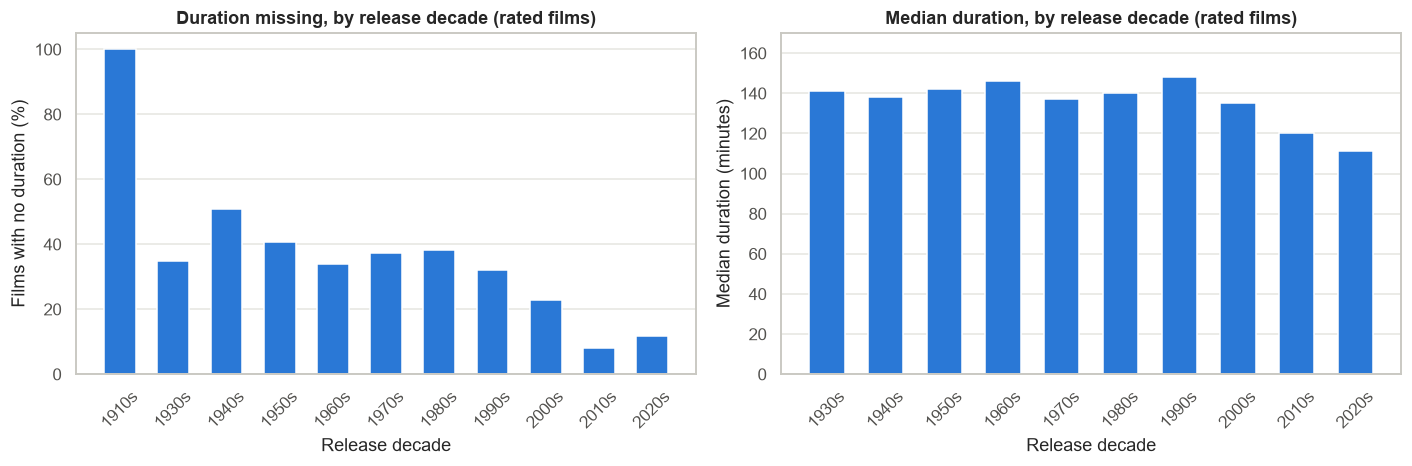

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
labels = [f"{d}s" for d in dur_by_decade.index]

axes[0].bar(labels, dur_by_decade["missing_pct"], color=PRIMARY, width=0.6)
axes[0].set_title("Duration missing, by release decade (rated films)")
axes[0].set_xlabel("Release decade")
axes[0].set_ylabel("Films with no duration (%)")
axes[0].grid(axis="x", visible=False)

known = dur_by_decade[dur_by_decade["duration_known"] > 0]
axes[1].bar([f"{d}s" for d in known.index], known["median_min"], color=PRIMARY, width=0.6)
axes[1].set_title("Median duration, by release decade (rated films)")
axes[1].set_xlabel("Release decade")
axes[1].set_ylabel("Median duration (minutes)")
axes[1].set_ylim(0, 170)
axes[1].grid(axis="x", visible=False)

for ax in axes:
    ax.tick_params(axis="x", labelrotation=45)
fig.tight_layout()
fig.savefig(FIG_DIR / "08_duration_missingness_by_decade.png", dpi=120, bbox_inches="tight")
plt.show()

The table below compares rated films with and without a duration. It is descriptive only and is used to decide
whether missingness should be preserved as a feature. It does **not** create any feature from `Rating`.

In [13]:
model_df.groupby(model_df["Duration_min"].isna().rename("duration_missing")).agg(
    films=("Rating", "size"),
    rating_mean=("Rating", "mean"),
    rating_median=("Rating", "median"),
    votes_median=("Votes_eda", "median"),
).round(2)

,films,rating_mean,rating_median,votes_median
duration_missing,,,,
False,5851,5.93,6.1,119.0
True,2068,5.59,5.7,15.0


**Observations**

- Missingness is **not random with respect to era**. Older decades have far more missing durations than the 2010s.
- Typical duration also **changes with era**: medians are around 135–148 minutes for the 1950s–2000s and drop
  for the 2010s and 2020s.
- Rated films without a duration have a lower average rating and far fewer votes, so missingness itself may carry
  information.

**Decision (missing duration):**

1. **Impute with the median duration of the film's release decade, learned from the training split only**
   (`NumericFeatureTransformer`). This respects the era difference that a single global mean or median would ignore.
2. Decades with fewer than 30 known durations in the training data fall back to the overall training median, so
   small groups do not produce unstable medians.
3. **Add a `duration_missing` indicator** so the model can still tell imputed values from observed ones.

The global mean was rejected because it ignores the era pattern and the distribution's spread.

## 8. Votes Cleaning (EDA Only)

`"25,732"` → `25732`. Only strings of digits with thousands separators are accepted.

In [14]:
votes_non_null = raw["Votes"].notna()
print(f"Non-null raw Votes values : {votes_non_null.sum():,}")
print(f"Parsed as vote counts     : {cleaned['Votes_eda'].notna().sum():,}")
print(f"Malformed (not parsed)    : {cleaned['votes_malformed'].sum()}")
cleaned.loc[cleaned["votes_malformed"], ["Name", "Year", "Genre", "Rating", "Votes", "Votes_eda"]]

Non-null raw Votes values : 7,920
Parsed as vote counts     : 7,919
Malformed (not parsed)    : 1


,Name,Year,Genre,Rating,Votes,Votes_eda
9500,Moonlight: Unfortunately a Love Story,2006.0,Comedy,NaN,$5.16M,<NA>


**The `"$5.16M"` value.** Every other vote value is a plain integer with thousands separators. This one has a currency
symbol, a decimal point and an `M` suffix, and its row has no `Rating`. The dataset contains no column that would let
us confirm what the value means. It resembles a monetary amount, but that is an interpretation.

**Decision:** the value is **not** converted to a vote count. `Votes_eda` is `NaN` for this row and `votes_malformed`
records the anomaly. Because the row is unrated, it is not part of the modeling dataframe anyway. The raw `Votes`
column is kept unchanged.

**Modeling assumption: `Votes` is excluded from the primary feature set.**

The intended prediction scenario is to estimate a film's rating from attributes of the film itself (genre,
director, cast, year, duration). `Votes` is accumulated audience activity and may not be available when such a
prediction is made. This is a **modeling assumption about the use case**, not a claim that `Votes` is inherently
leakage. `Votes_eda` stays in the modeling dataframe for EDA and a possible later secondary experiment, but it is
**not** in `FEATURE_COLUMNS`.

In [15]:
print("Feature columns passed to the transformer:", dp.FEATURE_COLUMNS)
assert "Votes" not in dp.FEATURE_COLUMNS and "Votes_eda" not in dp.FEATURE_COLUMNS
assert dp.TARGET not in dp.FEATURE_COLUMNS

Feature columns passed to the transformer: ['Year', 'Duration_min', 'Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']


## 9. Genre Preprocessing

`Genre` is split into individual tokens instead of treating each of the hundreds of combinations as a separate class.

In [16]:
tokens = model_df["Genre_list"].dropna().explode()
print(f"Distinct genre strings (modeling rows): {model_df['Genre'].nunique()}")
print(f"Distinct genre tokens  (modeling rows): {tokens.nunique()}")
print(f"Missing Genre          (modeling rows): {model_df['Genre'].isna().sum()} ({model_df['Genre'].isna().mean():.1%})")
print(f"Genres per film: {model_df['Genre_list'].dropna().str.len().value_counts().sort_index().to_dict()}")
tokens.value_counts().rename("films").to_frame().T

Distinct genre strings (modeling rows): 432
Distinct genre tokens  (modeling rows): 22
Missing Genre          (modeling rows): 102 (1.3%)
Genres per film: {1: 2711, 2: 2294, 3: 2812}


Genre_list,Drama,Action,Romance,Comedy,Crime,Thriller,Family,Musical,Adventure,Mystery,Horror,Fantasy,Documentary,Biography,History,Animation,Music,Sport,Sci-Fi,War,Western,News
films,4924,2358,1781,1609,1111,876,663,498,386,370,280,205,143,142,128,73,61,51,37,34,3,2


In [17]:
all_tokens = set(cleaned["Genre_list"].dropna().explode())
print("Tokens present in raw data but absent from rated rows:", sorted(all_tokens - set(tokens)))

Tokens present in raw data but absent from rated rows: ['Reality-TV', 'Short']


**Decision (Genre):** multi-hot encoding with `GenreMultiHotEncoder`.

- One binary column `genre=<Token>` per genre in the **training** vocabulary. A film tagged `Drama, Romance` gets
  1 in both columns.
- **Missing genre** is represented explicitly: all genre columns are 0 and `genre_missing = 1`. No genre is
  invented.
- `genre_count` records how many genres are listed.
- `Music` and `Musical` are kept as **separate** tokens because they are recorded as separate labels in the data.
  Merging them would be an assumption.
- Rare tokens (e.g. `News`, `Western`) are kept. The encoder has a `min_count` parameter if they need to be pruned
  later, and genres not seen during fitting are ignored at transform time.

In [18]:
examples = model_df.loc[[0, 1, 2], ["Name", "Genre", "Genre_list"]]
examples = pd.concat([examples, model_df.loc[model_df["Genre"].isna(), ["Name", "Genre", "Genre_list"]].head(2)])
examples

,Name,Genre,Genre_list
0,#Gadhvi (He thought he was Gandhi),Drama,[Drama]
1,#Yaaram,"Comedy, Romance","[Comedy, Romance]"
2,...Aur Pyaar Ho Gaya,"Comedy, Drama, Musical","[Comedy, Drama, Musical]"
42,25th July,NaN,NaN
43,26 January,NaN,NaN


## 10. Director Preprocessing Strategy

The frequency analysis below uses **only counts of films per director**. `Rating` is not involved.

In [19]:
director_counts = model_df["Director"].value_counts()
print(f"Distinct directors (modeling rows): {len(director_counts):,}")
print(f"Directors with exactly one rated film: {(director_counts == 1).sum():,} ({(director_counts == 1).mean():.1%})")
print(f"Missing Director: {model_df['Director'].isna().sum()}")

def coverage_table(counts, rows_covered):
    return pd.DataFrame([
        {"min_films": k, "names_kept": int((counts >= k).sum()), "films_covered": int(rows_covered(counts[counts >= k].index))}
        for k in [2, 3, 5, 10, 15, 20, 30]
    ]).set_index("min_films")

director_coverage = coverage_table(director_counts, lambda names: model_df["Director"].isin(names).sum())
director_coverage["pct_films_covered"] = (director_coverage["films_covered"] / len(model_df) * 100).round(1)
director_coverage

Distinct directors (modeling rows): 3,139
Directors with exactly one rated film: 2,021 (64.4%)
Missing Director: 5


,names_kept,films_covered,pct_films_covered
min_films,,,
2,1118,5893,74.4
3,697,5051,63.8
5,375,3974,50.2
10,157,2572,32.5
15,70,1547,19.5
20,30,880,11.1
30,14,502,6.3


One-hot encoding every director would create about 3,100 mostly single-film columns, which the model cannot learn from.

**Decision (Director):** `PeopleEncoder(prefix="director", min_count=10)` produces:

| Output | Meaning |
|---|---|
| `director_count` | Number of **training** films by this director (0 if unseen or missing). A frequency/experience signal that covers every director, including rare ones |
| `director_missing` | 1 if `Director` is empty |
| `director=<Name>` | One-hot columns only for directors with ≥ 10 training films |

- The threshold of 10 was chosen from the coverage table above, which is based on film counts, not ratings. On
  all rated rows it would keep about 157 directors covering about a third of the films. With a training subset
  the kept set will be smaller.
- Counts, and the set of kept names, are learned **inside `fit`**, so they come from the training split only.
- `min_count` is a parameter and can be tuned later with cross-validation on training data.
- **No target encoding** is used at this stage.

## 11. Actor Preprocessing Strategy

The same person can appear as `Actor 1` in one film and `Actor 3` in another (Phase 1), so actor frequencies are
counted **pooled across all three slots**.

In [20]:
actor_cols = dp.ACTOR_COLUMNS
names_per_film = model_df[actor_cols].apply(lambda r: set(r.dropna()), axis=1)
pooled_counts = names_per_film.explode().dropna().value_counts()
print(f"Distinct actors across slots (modeling rows): {len(pooled_counts):,}")
print(f"Actors with exactly one rated film: {(pooled_counts == 1).sum():,} ({(pooled_counts == 1).mean():.1%})")

repeated_within_film = model_df[actor_cols].apply(lambda r: r.dropna().duplicated().any(), axis=1)
print(f"Films listing the same actor in two slots: {repeated_within_film.sum()} (counted once per film)")
model_df.loc[repeated_within_film, ["Name", "Year", *actor_cols]].head(5)

Distinct actors across slots (modeling rows): 6,153
Actors with exactly one rated film: 4,092 (66.5%)


Films listing the same actor in two slots: 18 (counted once per film)


,Name,Year,Actor 1,Actor 2,Actor 3
32,2 Nights in Soul Valley,2012.0,Hemant Pandey,Sumeet Sharma,Sumeet Sharma
299,Aashmani Jawaharat,2014.0,Anamitra Roy,Anamitra Roy,Yovik
523,Amavas,2019.0,Ali Asgar,Ali Asgar,Vivan Bhatena
653,Antenna,2021.0,Imran Khan,Imran Khan,Azmat Khwaja
1865,Delhi 47 KM,2018.0,Shadab Khan,Shadab Khan,Shadab Khan


In [21]:
print("Actor missingness pattern (True = missing):")
model_df[actor_cols].isna().value_counts().rename("films").to_frame()

Actor missingness pattern (True = missing):


films
Actor 1 Actor 2 Actor 3       
False   False   False     7627
True    True    True       125
False   False   True        92
        True    True        75

In [22]:
actor_coverage = coverage_table(pooled_counts, lambda names: model_df[actor_cols].isin(names).any(axis=1).sum())
actor_coverage["pct_films_covered"] = (actor_coverage["films_covered"] / len(model_df) * 100).round(1)
actor_coverage

,names_kept,films_covered,pct_films_covered
min_films,,,
2,2061,7306,92.3
3,1334,7016,88.6
5,823,6683,84.4
10,430,6106,77.1
15,291,5664,71.5
20,220,5301,66.9
30,137,4632,58.5


- Missing actors are always the **trailing** slots: a film has 3, 2, 1 or 0 listed actors, never a gap in the middle.
- A small number of films list the same person twice; that person counts once for the film.

**Decision (Actors):** `PeopleEncoder(prefix="actor", min_count=20)` over `Actor 1`–`Actor 3` produces:

| Output | Meaning |
|---|---|
| `actor_1_count`, `actor_2_count`, `actor_3_count` | Number of **training** films the listed person appears in (any slot). 0 if unseen or missing |
| `actor_1_missing`, `actor_2_missing`, `actor_3_missing` | Missing-slot indicators |
| `actor_listed` | Number of actors listed (0–3) |
| `actor=<Name>` | Slot-independent multi-hot: 1 if the actor appears in any slot, only for actors with ≥ 20 training films |

On all rated rows, a threshold of 20 would keep about 220 actors and cover about two-thirds of the films (table above).
All counts and kept names are learned in `fit` on training data only. No `Rating` information is used, and no target
encoding is applied.

## 12. Duplicate Handling

### 12.1 Exact duplicates

In [23]:
exact = raw[raw.duplicated(keep=False)].sort_values(["Name", "Year"])
print(f"Exact duplicate rows (excluding first occurrence): {raw.duplicated().sum()}")
print(f"Of these, rows with a Rating: {row_log['exact_duplicates_with_rating']}")
exact

Exact duplicate rows (excluding first occurrence): 6
Of these, rows with a Rating: 0


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1249,Arab Ka Sona - Abu Kaalia,(1979),NaN,Action,NaN,NaN,Master Bhagwan,Meena Rai,Dara Singh,NaN
1250,Arab Ka Sona - Abu Kaalia,(1979),NaN,Action,NaN,NaN,Master Bhagwan,Meena Rai,Dara Singh,NaN
1768,Balidan,(1992),NaN,Drama,NaN,NaN,NaN,NaN,NaN,NaN
1769,Balidan,(1992),NaN,Drama,NaN,NaN,NaN,NaN,NaN,NaN
4722,First Time - Pehli Baar,(2009),NaN,NaN,NaN,NaN,Raja Bundela,Zeenat Aman,Nitin Arora,Raj Babbar
4723,First Time - Pehli Baar,(2009),NaN,NaN,NaN,NaN,Raja Bundela,Zeenat Aman,Nitin Arora,Raj Babbar
9712,Musafir,NaN,NaN,Thriller,NaN,NaN,Shiva Dagar,NaN,NaN,NaN
9713,Musafir,NaN,NaN,Thriller,NaN,NaN,Shiva Dagar,NaN,NaN,NaN
13068,Shivani,(2019),NaN,Crime,NaN,NaN,Ugresh Prasad Ujala,Santosh,NaN,NaN
13069,Shivani,(2019),NaN,Crime,NaN,NaN,Ugresh Prasad Ujala,Santosh,NaN,NaN


**Decision (exact duplicates):** remove them, keeping the first occurrence, **in the derived frame only**. Identical
rows add no information, and if they were rated they could later land on both sides of a train/test split.

In this dataset all 6 exact duplicates are unrated, so their removal does **not** change the modeling dataframe. The
step is kept in `build_modeling_frame` so the pipeline behaves correctly if the source data changes.

### 12.2 `Name` + `Year` repeats (not exact duplicates)

In [24]:
repeats = model_df[model_df["name_year_repeat"]].sort_values(["Name", "Year"])
print(f"Modeling rows sharing Name + Year with another modeling row: {len(repeats)}")
repeats[["raw_index", "Name", "Year", "Duration_min", "Genre", "Rating", "Votes", "Director", "Actor 1", "Actor 2"]]

Modeling rows sharing Name + Year with another modeling row: 6


,raw_index,Name,Year,Duration_min,Genre,Rating,Votes,Director,Actor 1,Actor 2
3187,6062,India's Daughter,2015.0,63.0,"Documentary, Biography, Crime",8.2,"1,998",Leslee Udwin,Asha Devi,Badri Singh
3188,6063,India's Daughter,2015.0,120.0,"Action, Crime, Drama",6.9,21,Rupesh Paul,Omkar Das Manikpuri,Amann Grewal
6359,12420,Sant Dnyaneshwar,1940.0,139.0,Fantasy,7.9,45,Vishnupant Govind Damle,Sheikh Fattelal,Shahu Modak
6360,12421,Sant Dnyaneshwar,1940.0,137.0,Biography,8.1,9,Vishnupant Govind Damle,Sheikh Fattelal,Shahu Modak
7575,14880,Vikram,1986.0,136.0,"Action, Adventure, Sci-Fi",7.3,504,Rajasekar,Kamal Haasan,Sathyaraj
7576,14881,Vikram,1986.0,<NA>,"Action, Drama, Romance",7.1,38,V. Madhusudan Rao,Nagarjuna Akkineni,Shobana


**Decision (Name + Year repeats):** **retain all of them.** They are marked with the column `name_year_repeat`, which is
an audit column, not a feature.

- `India's Daughter (2015)` and `Vikram (1986)` have different directors and casts, which suggests different films
  that share a title.
- `Sant Dnyaneshwar (1940)` has the same director and cast but different genre, duration, vote count and rating. It may
  be two records of one film. The data alone cannot settle this.

**Recommendation for the modeling phase:** use a group-aware split (grouping on `Name` + `Year`) so that records that
may describe the same film do not appear in both the training and the test data.

## 13. Missing-Value Handling

Missingness is measured **on the modeling rows**, and each feature gets a strategy suited to its type and extent.

In [25]:
strategy = {
    "Year": "None needed (0 missing). Training-median fallback exists for robustness.",
    "Duration_min": "Release-decade median from training data (global training median fallback) + duration_missing indicator.",
    "Genre": "No imputation. All genre columns 0 + genre_missing indicator.",
    "Director": "No imputation. director_count = 0 + director_missing indicator.",
    "Actor 1": "No imputation. actor_1_count = 0 + actor_1_missing indicator; actor_listed.",
    "Actor 2": "No imputation. actor_2_count = 0 + actor_2_missing indicator; actor_listed.",
    "Actor 3": "No imputation. actor_3_count = 0 + actor_3_missing indicator; actor_listed.",
}
missing_plan = pd.DataFrame({
    "missing": model_df[dp.FEATURE_COLUMNS].isna().sum(),
    "missing_pct": (model_df[dp.FEATURE_COLUMNS].isna().mean() * 100).round(2),
    "strategy": pd.Series(strategy),
})
missing_plan["substantial (>5%)"] = missing_plan["missing_pct"] > 5
missing_plan

,missing,missing_pct,strategy,substantial (>5%)
Year,0,0.00,None needed (0 missing). Training-median fallb...,False
Duration_min,2068,26.11,Release-decade median from training data (glob...,True
Genre,102,1.29,No imputation. All genre columns 0 + genre_mis...,False
Director,5,0.06,No imputation. director_count = 0 + director_m...,False
Actor 1,125,1.58,No imputation. actor_1_count = 0 + actor_1_mis...,False
Actor 2,200,2.53,No imputation. actor_2_count = 0 + actor_2_mis...,False
Actor 3,292,3.69,No imputation. actor_3_count = 0 + actor_3_mis...,False


**Reasoning**

- Only `Duration_min` has **substantial** missingness (26.1%). It is the only feature that gets imputed, and the
  imputation is era-aware and paired with an indicator.
- For the categorical person and genre fields, missingness is small (≤ 3.7%). Filling them with the most frequent
  name or genre would invent information, so missingness is encoded explicitly instead. The "Unknown" state is
  captured by the indicator columns rather than a fake category, so it cannot be mistaken for a real person or genre.
- `Rating` is never imputed; unrated rows are excluded (Section 5).

## 14. Data-Quality Validation

### 14.1 Modeling dataframe checks

In [26]:
checks = {
    "Rating has no missing values": model_df["Rating"].notna().all(),
    "Rating within [1, 10]": model_df["Rating"].between(1, 10).all(),
    "Year has no missing values": model_df["Year"].notna().all(),
    "Year within plausible range": model_df["Year"].between(dp.MIN_PLAUSIBLE_YEAR, pd.Timestamp.now().year).all(),
    "Duration positive where present": (model_df["Duration_min"].dropna() > 0).all(),
    "No exact duplicate rows (raw columns)": not model_df[dp.RAW_COLUMNS].duplicated().any(),
    "No malformed Votes in modeling rows": not model_df["votes_malformed"].any(),
    "Votes_eda non-missing in modeling rows": model_df["Votes_eda"].notna().all(),
    "raw_index values unique": model_df["raw_index"].is_unique,
    "Rows = rated raw rows − rated exact duplicates": len(model_df) == raw["Rating"].notna().sum() - row_log["exact_duplicates_with_rating"],
    "Target not in feature columns": dp.TARGET not in dp.FEATURE_COLUMNS,
    "Votes not in feature columns": not {"Votes", "Votes_eda"} & set(dp.FEATURE_COLUMNS),
    "Raw frame unchanged in memory": raw.equals(raw_snapshot),
}
check_results = pd.Series(checks, name="passed").to_frame()
assert check_results["passed"].all(), check_results[~check_results["passed"]]
check_results

,passed
Rating has no missing values,True
"Rating within [1, 10]",True
Year has no missing values,True
Year within plausible range,True
Duration positive where present,True
No exact duplicate rows (raw columns),True
No malformed Votes in modeling rows,True
Votes_eda non-missing in modeling rows,True
raw_index values unique,True
Rows = rated raw rows − rated exact duplicates,True


### 14.2 Feature transformer smoke test

This test checks that the transformer **runs correctly**: output is fully numeric, there are no missing values,
unseen names are handled, and using it before fitting raises an error.

To avoid fitting on the whole dataset, the transformer is fitted on an **arbitrary block of 1,000 rows** and applied
to the next 500. This is a software check, **not** a train/test split. The fitted object and its outputs are
discarded, and no model is trained.

In [27]:
X, y = dp.get_features_and_target(model_df)
print(f"X shape: {X.shape}, y shape: {y.shape}")
print("X columns:", X.columns.tolist())

transformer = dp.build_feature_transformer()
try:
    transformer.transform(X.head())
    raise AssertionError("transform() should fail before fit()")
except NotFittedError:
    print("Unfitted transformer correctly refuses to transform.")

X shape: (7919, 7), y shape: (7919,)
X columns: ['Year', 'Duration_min', 'Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']
Unfitted transformer correctly refuses to transform.


In [28]:
fit_block, apply_block = X.iloc[:1000], X.iloc[1000:1500]
smoke = dp.build_feature_transformer().fit(fit_block)
smoke_out = smoke.transform(apply_block)

print(f"Output shape                 : {smoke_out.shape}")
print(f"Missing values in output     : {int(smoke_out.isna().sum().sum())}")
print(f"All columns numeric          : {all(pd.api.types.is_numeric_dtype(t) for t in smoke_out.dtypes)}")
print(f"Index preserved              : {smoke_out.index.equals(apply_block.index)}")
print(f"Deterministic on re-transform: {smoke_out.equals(smoke.transform(apply_block))}")

director_enc = smoke.named_transformers_["director"]
unseen_directors = ~apply_block["Director"].isin(director_enc.name_counts_) & apply_block["Director"].notna()
print(f"Unseen directors in applied block: {unseen_directors.sum()} → director_count all 0: "
      f"{(smoke_out.loc[unseen_directors, 'director_count'] == 0).all()}")
assert smoke_out.notna().all().all()

Output shape                 : (500, 47)
Missing values in output     : 0
All columns numeric          : True
Index preserved              : True


Deterministic on re-transform: True
Unseen directors in applied block: 319 → director_count all 0: True


In [29]:
groups = {name: len(t.get_feature_names_out()) for name, t, _ in smoke.transformers_ if name != "remainder"}
print("Output columns per group (from the 1,000-row smoke fit; real counts depend on the training data):")
print(groups)
smoke_out.head()

Output columns per group (from the 1,000-row smoke fit; real counts depend on the training data):
{'numeric': 3, 'genre': 22, 'director': 6, 'actors': 16}


,Year,Duration_min,duration_missing,genre=Action,genre=Adventure,genre=Animation,genre=Biography,genre=Comedy,genre=Crime,genre=Documentary,genre=Drama,genre=Family,genre=Fantasy,genre=History,genre=Horror,genre=Music,genre=Musical,genre=Mystery,genre=Romance,genre=Sci-Fi,genre=Sport,genre=Thriller,genre=War,genre_missing,genre_count,director_count,director_missing,director=Hrishikesh Mukherjee,director=J. Om Prakash,director=Mohan Kumar,director=Shakti Samanta,actor_1_count,actor_2_count,actor_3_count,actor_1_missing,actor_2_missing,actor_3_missing,actor_listed,actor=Amitabh Bachchan,actor=Ashok Kumar,actor=Dharmendra,actor=Jackie Shroff,actor=Jeetendra,actor=Mithun Chakraborty,actor=Raj Babbar,actor=Rajesh Khanna,actor=Sanjeev Kumar
1000,2015.0,135.0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,2,0,3,0,0,0,3,0,0,0,0,0,0,0,0,0
1001,1991.0,145.0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,2,5,0,0,0,0,0,12,6,5,0,0,0,3,0,0,0,0,0,0,0,0,0
1002,2016.0,137.0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,3,1,0,0,0,0,3,0,0,0,0,0,0,0,0,0
1003,2017.0,120.0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,3,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0
1004,1971.0,136.5,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,2,3,0,0,0,0,0,25,3,16,0,0,0,3,0,0,0,0,1,0,0,0,0


## 15. Final Feature Overview

The input to the transformer is `FEATURE_COLUMNS`. Its output after fitting on a training split is summarised below.
The number of one-hot or multi-hot columns depends on the training data, because the vocabulary and thresholds are
applied at fit time.

| Group | Input column(s) | Output features | Fitted statistics (training only) |
|---|---|---|---|
| Numeric | `Year`, `Duration_min` | `Year`, `Duration_min` (imputed), `duration_missing` | Year median; per-decade and overall Duration medians |
| Genre | `Genre` | `genre=<Token>` multi-hot, `genre_missing`, `genre_count` | Genre vocabulary |
| Director | `Director` | `director_count`, `director_missing`, `director=<Name>` for directors with ≥ 10 films | Director film counts |
| Actors | `Actor 1`–`Actor 3` | `actor_{1,2,3}_count`, `actor_{1,2,3}_missing`, `actor_listed`, `actor=<Name>` for actors with ≥ 20 films | Pooled actor film counts |

**Not used as features:** `Name` (identifier), `Votes`/`Votes_eda` (modeling assumption), `Rating` (target), and the
audit columns `duration_questionable`, `votes_malformed`, `name_year_repeat`, `raw_index`, `Year_raw`, `Genre_list`.

**Scaling** is not applied here: whether it is needed depends on the model chosen in the next phase, and it can then
be added to the pipeline and fitted on training data only.

In [30]:
pd.DataFrame([
    {"column": c, "role": "feature input" if c in dp.FEATURE_COLUMNS else
                          "target" if c == dp.TARGET else
                          "excluded" if c in dp.NON_FEATURE_COLUMNS else "audit / traceability",
     "reason": dp.NON_FEATURE_COLUMNS.get(c, "")}
    for c in model_df.columns
]).set_index("column")

,role,reason
column,,
raw_index,audit / traceability,
Name,excluded,"Title identifier, near-unique per film; not a ..."
Year,feature input,
Duration,audit / traceability,
Genre,feature input,
Rating,target,Target variable.
Votes,excluded,"Raw vote text, kept unchanged for traceability..."
Director,feature input,
Actor 1,feature input,


## 16. Final Modeling Dataframe Summary

In [31]:
print(f"Shape: {model_df.shape[0]:,} rows × {model_df.shape[1]} columns")
model_df.info()

Shape: 7,919 rows × 18 columns
<class 'pandas.DataFrame'>
RangeIndex: 7919 entries, 0 to 7918
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   raw_index              7919 non-null   int64  
 1   Name                   7919 non-null   str    
 2   Year                   7919 non-null   Float64
 3   Duration               5851 non-null   str    
 4   Genre                  7817 non-null   str    
 5   Rating                 7919 non-null   float64
 6   Votes                  7919 non-null   str    
 7   Director               7914 non-null   str    
 8   Actor 1                7794 non-null   str    
 9   Actor 2                7719 non-null   str    
 10  Actor 3                7627 non-null   str    
 11  Year_raw               7919 non-null   str    
 12  Duration_min           5851 non-null   Float64
 13  duration_questionable  7919 non-null   bool   
 14  Votes_eda              7919 non-null

In [32]:
model_df["Rating"].describe().round(3).to_frame("Rating (target)").T

,count,mean,std,min,25%,50%,75%,max
Rating (target),7919.0,5.842,1.382,1.1,4.9,6.0,6.8,10.0


In [33]:
model_df.head()

,raw_index,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3,Year_raw,Duration_min,duration_questionable,Votes_eda,votes_malformed,Genre_list,name_year_repeat
0,1,#Gadhvi (He thought he was Gandhi),2019.0,109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid,(2019),109.0,False,8.0,False,[Drama],False
1,3,#Yaaram,2019.0,110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor,(2019),110.0,False,35.0,False,"[Comedy, Romance]",False
2,5,...Aur Pyaar Ho Gaya,1997.0,147 min,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor,(1997),147.0,False,827.0,False,"[Comedy, Drama, Musical]",False
3,6,...Yahaan,2005.0,142 min,"Drama, Romance, War",7.4,"1,086",Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma,(2005),142.0,False,1086.0,False,"[Drama, Romance, War]",False
4,8,?: A Question Mark,2012.0,82 min,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia,(2012),82.0,False,326.0,False,"[Horror, Mystery, Thriller]",False


## 17. Preprocessing Decisions Summary

In [34]:
end_hash = file_sha256(DATA_PATH)
assert end_hash == PHASE1_SHA256

summary = {
    "Raw dataset rows": f"{len(raw):,}",
    "Rated rows in raw data": f"{raw['Rating'].notna().sum():,}",
    "Exact duplicates removed (derived frame only)": f"{row_log['exact_duplicates_removed']} (rated among them: {row_log['exact_duplicates_with_rating']})",
    "Unrated rows excluded": f"{row_log['unrated_rows_excluded']:,}",
    "Final modeling dataframe rows": f"{len(model_df):,}",
    "Target column": dp.TARGET,
    "Candidate feature inputs": ", ".join(dp.FEATURE_COLUMNS),
    "Missing values remaining in feature inputs (before fitted imputation)":
        ", ".join(f"{c}: {n}" for c, n in model_df[dp.FEATURE_COLUMNS].isna().sum().items() if n) or "none",
    "Missing values after transformer (smoke test)": int(smoke_out.isna().sum().sum()),
    "Name + Year repeats": f"{int(model_df['name_year_repeat'].sum())} rows retained and flagged",
    "Raw CSV unchanged (SHA-256 matches Phase 1)": end_hash == PHASE1_SHA256,
}
width = max(map(len, summary))
for key, value in summary.items():
    print(f"{key:<{width}} : {value}")

Raw dataset rows                                                      : 15,509
Rated rows in raw data                                                : 7,919
Exact duplicates removed (derived frame only)                         : 6 (rated among them: 0)
Unrated rows excluded                                                 : 7,584
Final modeling dataframe rows                                         : 7,919
Target column                                                         : Rating
Candidate feature inputs                                              : Year, Duration_min, Genre, Director, Actor 1, Actor 2, Actor 3
Missing values remaining in feature inputs (before fitted imputation) : Duration_min: 2068, Genre: 102, Director: 5, Actor 1: 125, Actor 2: 200, Actor 3: 292
Missing values after transformer (smoke test)                         : 0
Name + Year repeats                                                   : 6 rows retained and flagged
Raw CSV unchanged (SHA-256 matches Phase 1)  

### Transformations applied

| Step | Where | Fitted on data? |
|---|---|---|
| Strip whitespace in text fields; empty strings → missing | `clean_movies` | No |
| `Year`: `"(YYYY)"` → number (strict pattern, non-matching → missing) | `clean_movies` | No |
| `Duration`: `"N min"` → number; `duration_questionable` audit flag (< 40 min) | `clean_movies` | No |
| `Votes`: `"25,732"` → number for EDA; `"$5.16M"` not converted, flagged `votes_malformed` | `clean_movies` | No |
| `Genre` split into token lists | `clean_movies` | No |
| Exact duplicate rows removed (first kept) | `build_modeling_frame` | No |
| Unrated rows excluded (`Rating` never imputed) | `build_modeling_frame` | No |
| `Name` + `Year` repeats flagged, retained | `build_modeling_frame` | No |
| Year median fallback; Duration decade-median imputation + indicator | `NumericFeatureTransformer` | **Yes, training only** |
| Genre multi-hot + missing indicator + count | `GenreMultiHotEncoder` | **Yes, training only** |
| Director count + missing indicator + one-hot (≥ 10 films) | `PeopleEncoder` | **Yes, training only** |
| Actor pooled counts + missing indicators + listed count + multi-hot (≥ 20 films) | `PeopleEncoder` | **Yes, training only** |

### Key decisions

1. **Target:** `Rating`. Only the 7,919 rated rows are used; missing ratings are never filled.
2. **Votes:** cleaned for EDA only and excluded from the primary features. This is a modeling assumption about the
   prediction scenario, not a leakage claim.
3. **Duration:** era-aware (release-decade) median imputation learned from training data, plus a missing indicator.
   Short durations are retained; the single sub-40-minute rated film is flagged for review only.
4. **Genre:** multi-hot over individual tokens; missing genre is encoded explicitly, never invented.
5. **Director / actors:** training-fitted frequency counts plus one-hot or multi-hot columns for frequent names only.
   No target encoding.
6. **Duplicates:** 6 exact duplicates removed from the derived frame (none rated). `Name` + `Year` repeats retained and
   flagged; group-aware splitting is recommended.
7. **Leakage safety:** every data-dependent statistic lives inside a transformer's `fit`, to be called on the
   training split only. No feature uses `Rating`.

*No model was trained, no train/test split was made, and the raw CSV was not modified.*